[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/benchuangxd/CSC3109-T16-Project/blob/main/notebooks/06_vit_b16.ipynb)

# ViT-B/16

**CSC3109 - Machine Learning | Team 16 -- Member 5**

In [1]:
# -- Google Colab Setup -------------------------------------------------------
# Run this cell first when using Google Colab. No effect when running locally.
import sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess
    from pathlib import Path

    REPO_URL  = "https://github.com/benchuangxd/CSC3109-T16-Project.git"
    REPO_PATH = Path("/content/CSC3109-T16-Project")

    if not REPO_PATH.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_PATH)], check=True)
    else:
        print(f"Repo already exists at {REPO_PATH}")

    %cd /content/CSC3109-T16-Project
    %pip install -q -r requirements.txt
    print("Colab setup complete.")
else:
    print("Running locally -- skipping Colab setup.")

/content/CSC3109-T16-Project
Colab setup complete.


In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.config import DATA_DIR, CLASS_NAMES, NUM_CLASSES, IMAGE_SIZE, BATCH_SIZE, NUM_EPOCHS, SEED, TRAIN_RATIO
from src.utils import set_seed, get_device

set_seed(SEED)
DEVICE = get_device()
print(f"ROOT   : {ROOT}")
print(f"Device : {DEVICE}")
print(f"Classes: {CLASS_NAMES}")
print(f"Split  : {TRAIN_RATIO:.0%} train / {1-TRAIN_RATIO:.0%} val")

ROOT   : /content/CSC3109-T16-Project
Device : cuda
Classes: ['beach', 'ferry_terminal', 'harbor', 'river']
Split  : 70% train / 30% val


## 1. Data Loading

The dataloader applies the project split policy: a deterministic 70/30 split inside each class folder in `data/set 16` (`beach`, `ferry_terminal`, `harbor`, `river`). This keeps every class at 490 train and 210 validation images.

In [3]:
from src.dataset import get_dataloaders

train_loader, val_loader, classes = get_dataloaders(
    root        = ROOT,
    data_dir    = DATA_DIR,
    batch_size  = BATCH_SIZE,
    image_size  = IMAGE_SIZE,
    train_ratio = TRAIN_RATIO,
    seed        = SEED,
    num_workers = 2,
)

def subset_class_counts(subset, class_names):
    targets = subset.dataset.targets
    counts = {cls: 0 for cls in class_names}
    for idx in subset.indices:
        counts[class_names[targets[idx]]] += 1
    return counts

print(f"Classes       : {classes}")
print(f"Split policy  : {TRAIN_RATIO:.0%}/{1-TRAIN_RATIO:.0%} inside each class folder")
print(f"Train batches : {len(train_loader)}  ({len(train_loader.dataset)} images)")
print(f"Val batches   : {len(val_loader)}  ({len(val_loader.dataset)} images)")
print(f"Train counts  : {subset_class_counts(train_loader.dataset, classes)}")
print(f"Val counts    : {subset_class_counts(val_loader.dataset, classes)}")

Classes       : ['beach', 'ferry_terminal', 'harbor', 'river']
Split policy  : 70%/30% inside each class folder
Train batches : 62  (1960 images)
Val batches   : 27  (840 images)
Train counts  : {'beach': 490, 'ferry_terminal': 490, 'harbor': 490, 'river': 490}
Val counts    : {'beach': 210, 'ferry_terminal': 210, 'harbor': 210, 'river': 210}


## 2. Model Setup

ViT-B/16 splits each 224x224 image into 16x16 patches (196 patches total) and processes them through 12 transformer encoder blocks. We load ImageNet pretrained weights and replace only the classification head for our 4 classes.

In [4]:
from src.models import get_vit_b16
from src.utils import count_parameters

model = get_vit_b16(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(DEVICE)

total_params = count_parameters(model)
print(f"Trainable parameters : {total_params / 1e6:.2f} M")
print(f"Model head           : {model.heads.head}")
print(f"Running on           : {DEVICE}")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 148MB/s]


Trainable parameters : 85.80 M
Model head           : Linear(in_features=768, out_features=4, bias=True)
Running on           : cuda


## 3. Training

ViT fine-tuning is sensitive to learning rate -- we use **AdamW** with a small lr (1e-4) and **CosineAnnealingLR** to decay smoothly. This avoids destroying the pretrained representations.

In [5]:
import torch
from pathlib import Path
from src.train import train

SAVE_PATH = ROOT / "results" / "saved_models" / "vit_b16.pth"
LR        = 1e-4
WD        = 0.01

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history = train(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    optimizer    = optimizer,
    scheduler    = scheduler,
    num_epochs   = NUM_EPOCHS,
    device       = DEVICE,
    save_path    = SAVE_PATH,
)

Epoch [01/20]  train loss: 0.1710  train acc: 0.9372  val loss: 0.0635  val acc: 0.9774  (81.4s)
  -> Best model saved to /content/CSC3109-T16-Project/results/saved_models/vit_b16.pth  (val_acc=0.9774)
Epoch [02/20]  train loss: 0.0770  train acc: 0.9719  val loss: 0.0507  val acc: 0.9786  (85.4s)
  -> Best model saved to /content/CSC3109-T16-Project/results/saved_models/vit_b16.pth  (val_acc=0.9786)
Epoch [03/20]  train loss: 0.0834  train acc: 0.9684  val loss: 0.0431  val acc: 0.9786  (84.7s)
Epoch [04/20]  train loss: 0.0590  train acc: 0.9755  val loss: 0.0202  val acc: 0.9929  (84.3s)
  -> Best model saved to /content/CSC3109-T16-Project/results/saved_models/vit_b16.pth  (val_acc=0.9929)
Epoch [05/20]  train loss: 0.0752  train acc: 0.9704  val loss: 0.0598  val acc: 0.9786  (84.9s)
Epoch [06/20]  train loss: 0.0388  train acc: 0.9847  val loss: 0.0279  val acc: 0.9917  (84.2s)
Epoch [07/20]  train loss: 0.0588  train acc: 0.9760  val loss: 0.0390  val acc: 0.9869  (84.2s)
Epoch 

## 4. Training Curves

Training curves saved to /content/CSC3109-T16-Project/results/training_curves/vit_b16_training_curve.png


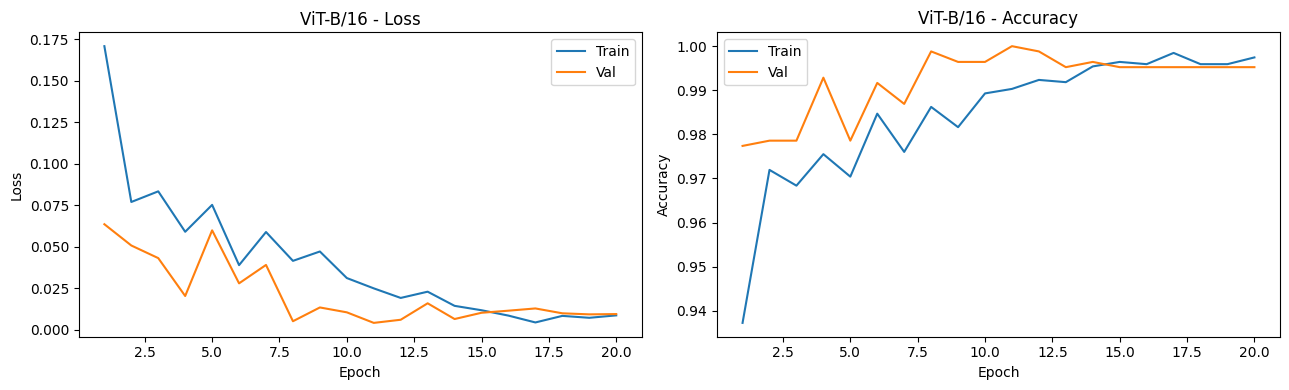

In [6]:
from src.utils import plot_training_curves

CURVES_PATH = ROOT / "results" / "training_curves" / "vit_b16_training_curve.png"

plot_training_curves(history, title="ViT-B/16", save_path=CURVES_PATH)

## 5. Evaluation

In [7]:
import torch
from src.evaluate import get_predictions, compute_metrics, print_report

# Load best saved weights before evaluating
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))

y_pred, y_true = get_predictions(model, val_loader, DEVICE)
metrics        = compute_metrics(y_true, y_pred)

print("=" * 40)
print(f"  Accuracy  : {metrics['accuracy']:.4f}")
print(f"  Precision : {metrics['precision']:.4f}")
print(f"  Recall    : {metrics['recall']:.4f}")
print(f"  F1 Score  : {metrics['f1_score']:.4f}")
print("=" * 40)
print()
print_report(y_true, y_pred, CLASS_NAMES)

  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000

                precision    recall  f1-score   support

         beach       1.00      1.00      1.00       210
ferry_terminal       1.00      1.00      1.00       210
        harbor       1.00      1.00      1.00       210
         river       1.00      1.00      1.00       210

      accuracy                           1.00       840
     macro avg       1.00      1.00      1.00       840
  weighted avg       1.00      1.00      1.00       840



## 6. Confusion Matrix

Confusion matrix saved to /content/CSC3109-T16-Project/results/confusion_matrices/vit_b16_confusion_matrix.png


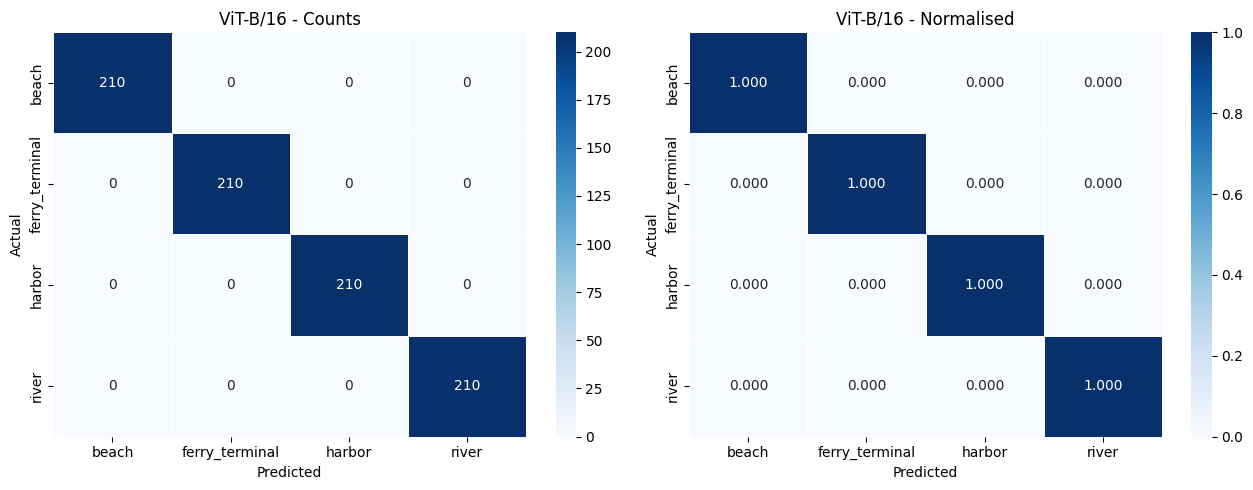

In [8]:
from src.evaluate import plot_confusion_matrix

CM_PATH = ROOT / "results" / "confusion_matrices" / "vit_b16_confusion_matrix.png"

plot_confusion_matrix(y_true, y_pred, CLASS_NAMES, title="ViT-B/16", save_path=CM_PATH)

## 7. Save Metrics

In [9]:
from src.utils import save_metrics_to_csv

METRICS_PATH = ROOT / "results" / "metrics.csv"

save_metrics_to_csv("vit_b16", metrics, METRICS_PATH)
print("Results written to results/metrics.csv")

Metrics saved to /content/CSC3109-T16-Project/results/metrics.csv
Results written to results/metrics.csv


## 8. Sample Predictions

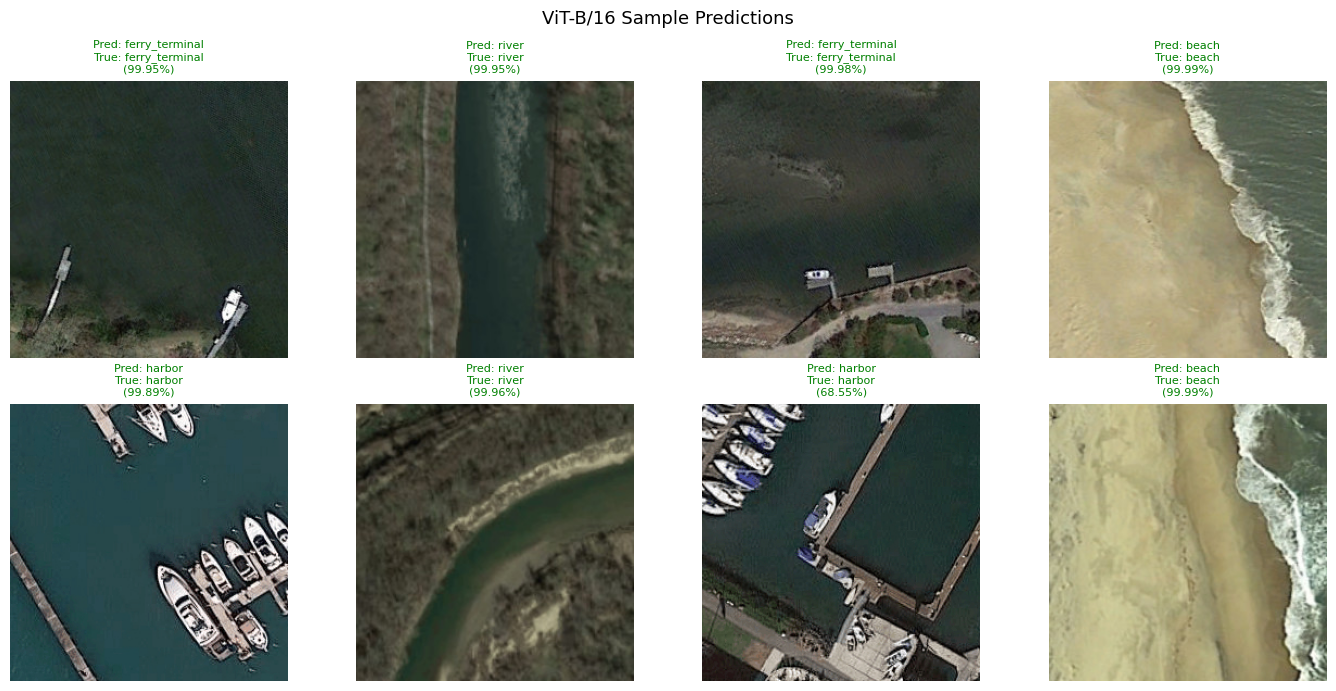

In [10]:
import random
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from src.predict import predict_image

val_subset = val_loader.dataset
val_paths_by_class = {cls: [] for cls in classes}
for idx in val_subset.indices:
    path, target = val_subset.dataset.samples[idx]
    val_paths_by_class[classes[target]].append(Path(path))

sample_paths = []
for cls in classes:
    imgs = val_paths_by_class[cls]
    sample_paths.extend(random.sample(imgs, min(2, len(imgs))))

random.shuffle(sample_paths)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("ViT-B/16 Sample Predictions", fontsize=13)

for ax, path in zip(axes.flat, sample_paths[:8]):
    label, conf, _ = predict_image(path, model, classes, DEVICE, IMAGE_SIZE)
    true_cls = path.parent.name
    img = Image.open(path).convert("RGB")
    ax.imshow(img)
    ax.axis("off")
    color = "green" if label == true_cls else "red"
    title = f"Pred: {label}\nTrue: {true_cls}\n({conf:.2%})"
    ax.set_title(title, fontsize=8, color=color)

plt.tight_layout()
plt.show()